In [1]:
import os
import numpy as np
from scipy.signal import butter, filtfilt
import ezc3d
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. SETUP PATHS & DIRECTORIES
# ==========================================
database = "DB1"
participant = "P01"

input_dir = f'../data/{database}_retargeted/{participant}'
output_dir = f'../data/{database}_filtered/{participant}'
os.makedirs(output_dir, exist_ok=True)   # If it doesn't exist, create

### Visualization of data before and after filtering

In [7]:
def plot_filter_preview(file_path, marker_name="LHEE", force_channel="FZ", cutoff=10.0):
    """Loads a single C3D file and plots raw vs filtered signals side-by-side."""
    c3d = ezc3d.c3d(file_path)
    fs_m, fs_a = c3d['header']['points']['frame_rate'], c3d['header']['analogs']['frame_rate']

    # Extract labels and search for targets
    m_labels = c3d['parameters']['POINT']['LABELS']['value']
    a_labels = c3d['parameters']['ANALOG']['LABELS']['value']
    m_idx = next((i for i, l in enumerate(m_labels) if marker_name.upper() in l.upper()), None)
    a_idx = next((i for i, l in enumerate(a_labels) if force_channel.upper() in l.upper()), None)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    fig.suptitle(f"Filter Preview ({cutoff} Hz) - {os.path.basename(file_path)}", fontweight='bold')

    # Plot Marker (Z-axis / Vertical)
    if m_idx is not None:
        raw = c3d['data']['points'][2, m_idx, :] # 2 = Z component
        filt = butter_lowpass_filter(raw, cutoff, fs_m)
        axes[0].plot(raw, 'gray', alpha=0.5, label='Raw')
        axes[0].plot(filt, 'crimson', label=f'Filtered {marker_name}')
        axes[0].legend()

    # Plot GRF Analog
    if a_idx is not None:
        raw = c3d['data']['analogs'][0, a_idx, :]
        filt = butter_lowpass_filter(raw, cutoff, fs_a)
        axes[1].plot(raw, 'gray', alpha=0.5, label='Raw')
        axes[1].plot(filt, 'royalblue', label=f'Filtered {a_labels[a_idx]}')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

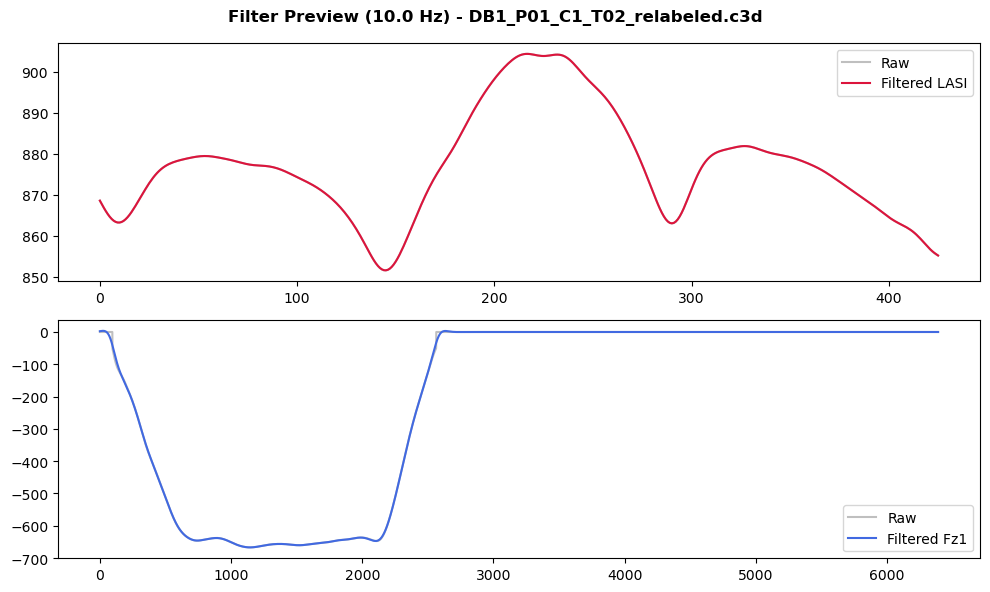

In [8]:
# Get the first available file name from your input directory
c3d_files = [f for f in os.listdir(input_dir) if f.endswith('.c3d')]

if c3d_files:
    test_file_path = os.path.join(input_dir, c3d_files[1])

    # Call the clean function (you can swap "LASI" or "FZ" for other labels here)
    plot_filter_preview(test_file_path, marker_name="LASI", force_channel="Fz")
else:
    print("No C3D files found to preview.")

### Filtering data

In [5]:
# ==========================================
# 2. DEFINE THE BUTTERWORTH FILTER
# ==========================================
def butter_lowpass_filter(data, cutoff, fs, order=2):
    """
    Applies a zero-phase (bidirectional) low-pass Butterworth filter.
    data: 1D or 2D array (time axis must be the last axis, or specified)
    cutoff: Cut-off frequency in Hz
    fs: Sampling frequency of the data in Hz
    order: Order of the single-pass filter (2 results in 4th order total via filtfilt)
    """
    nyq = 0.5 * fs  # Nyquist Frequency
    normal_cutoff = cutoff / nyq

    # Design the filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    # Apply bidirectionally along the last axis (time/frames)
    filtered_data = filtfilt(b, a, data, axis=-1)
    return filtered_data

In [9]:
# ==========================================
# 3. BATCH PROCESS ALL C3D FILES
# ==========================================
# Find all .c3d files in the input directory 
c3d_files = [f for f in os.listdir(input_dir) if f.endswith('.c3d')]

if not c3d_files:
    print(f"No C3D files found in: {input_dir}")
else:
    print(f"Found {len(c3d_files)} file(s) to process.\n" + "="*50)

# Target cutoff frequency
cutoff_freq = 10.0  # Hz

for file_name in c3d_files:
    # Create the full input path
    file_path = os.path.join(input_dir, file_name)
    # Extract the original filename without the extension
    base_name = os.path.splitext(file_name)[0]

    # Define the new filtered filename and its complete output path
    output_filename = f"{base_name}_filtered.c3d"
    output_path = os.path.join(output_dir, output_filename)
    
    try:
        # Load C3D file
        c3d = ezc3d.c3d(file_path)
        
        # Extract sampling frequencies
        fs_markers = c3d['header']['points']['frame_rate']
        fs_analogs = c3d['header']['analogs']['frame_rate']
        
        # Filter Marker Trajectories (X, Y, Z coordinates)
        markers_data = c3d['data']['points']
        filtered_markers = butter_lowpass_filter(markers_data[:3, :, :], cutoff=cutoff_freq, fs=fs_markers)
        c3d['data']['points'][:3, :, :] = filtered_markers
        
        # Filter Analog Data (GRF) if it exists
        if c3d['data']['analogs'].size > 0:
            analogs_data = c3d['data']['analogs']
            filtered_analogs = butter_lowpass_filter(analogs_data, cutoff=cutoff_freq, fs=fs_analogs)
            c3d['data']['analogs'] = filtered_analogs
            analog_status = "with analogs"
        else:
            analog_status = "no analogs found"
            
        # Write back to the new filtered directory
        c3d.write(output_path)
        print(f"-> Successfully exported ({analog_status}): {output_filename}")
        
    except Exception as e:
        print(f"❌ Error processing {base_name}.c3d{str(e)}")

print("="*50 + "\nBatch processing complete!")

Found 16 file(s) to process.
-> Successfully exported (with analogs): DB1_P01_C1_T01_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C1_T02_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C1_T03_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C1_T04_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C1_T05_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C2_T01_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C2_T02_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C2_T03_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C2_T04_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C2_T05_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C3_T01_relabeled_filtered.c3d
-> Successfully exported (with analogs): DB1_P01_C3_T02_relabeled_filtered.c3d
-> Successfully exporte